# Post-run analysis

In the last tutorial, we simulated a Lennard-Jones crystal and stored data in the file `'LJ_T0.70.h5'`.
In this tutorial, we will analyse this data. Below, we will do some standard imports and load the data from the file on the disk.

In [1]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
import h5py
import gamdpy as gp

# Select h5 file
filename='./LJ_T0.70.h5'
output = gp.tools.TrajectoryIO(filename).get_h5()

Found .h5 file (./LJ_T0.70.h5), loading to gamdpy as output dictionary


## Brief about the h5 data file

### Large data sets

Large data sets, such as the trajectory of particle positions, are stored as an HDF5 dataset (a data structure similar to a NumPy array, but data is stored on the disk).

In [2]:
nblocks, nconfs, N, D = output['trajectory/positions'].shape
print(f'Number of timeblocks:          {nblocks = }')
print(f'Configurations per timeblock:  {nconfs = }')
print(f'Number of particles:           {N = }')
print(f'Number of spatial dimensions:  {D = }')

Number of timeblocks:          nblocks = 8
Configurations per timeblock:  nconfs = 12
Number of particles:           N = 2048
Number of spatial dimensions:  D = 3


### Information in attributes

Some information, such as details about the simulation box, is stored as attributes. Below, we fetch such data to get the density of the NVT simulation.

In [3]:
simbox = output['initial_configuration'].attrs['simbox_data']
volume = np.prod(simbox)
rho = N/volume
print(f'Density:  {rho = :.5f}')

Density:  rho = 0.97300


## Thermodynamics

The gamdpy package contains helper functions to read data in .h5 files.
Thermodynamic data, stored in the `'scalar_saver'` group, can be extracted using the `gp.extract_scalars()` function (we skip the first block with `first_block=1` since the system is not equilibrated).

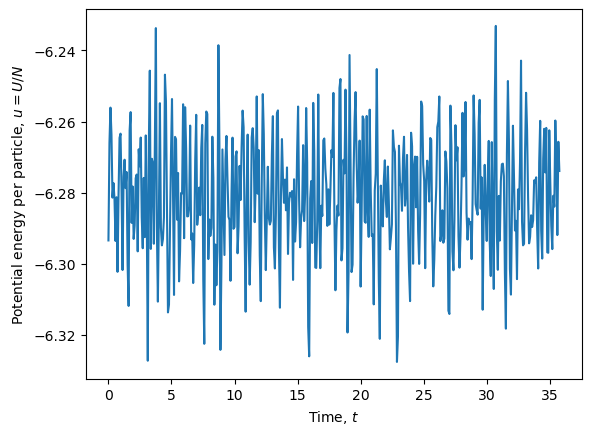

In [4]:
# Extract thermodynamic data
U, W, K = gp.ScalarSaver.extract(output, ['U', 'W', 'K'], per_particle=False, first_block=1)

# Get the associated times
times = gp.ScalarSaver.get_times(output, first_block=1)

# Plot potential energy per particle as a function of time
plt.figure()
plt.plot(times, U/N)
plt.xlabel(r'Time, $t$')
plt.ylabel('Potential energy per particle, $u=U/N$')
plt.show()

Some properties need to be computed from the data stored. Examples are the kinetic temperature and pressure (in LJ units).

In [5]:
# Compute instantaneous kinetic temperature
dof = D * N - D  # degrees of freedom
T_kin = 2 * K / dof

# Compute instantaneous pressure
P = rho * T_kin + W / volume

print(f'Mean kinetic temperature:  {np.mean(T_kin) = :.5f}')
print(f'Mean pressure:             {np.mean(P) = :.5f}')

Mean kinetic temperature:  np.mean(T_kin) = 0.70031
Mean pressure:             np.mean(P) = 1.40649


## Structure

To investigate the structure and dynamics of particles, we need to analyse data in the `'trajectory_saver'` group. Again, gamdpy has some built-in functionality to compute various measures. Let us calculate the radial distribution function. We will do this by inserting positions into a configuration object, and using the `gamdpy.CalculatorRadialDistribution()` class. The calculation is done on the GPU (for efficency).

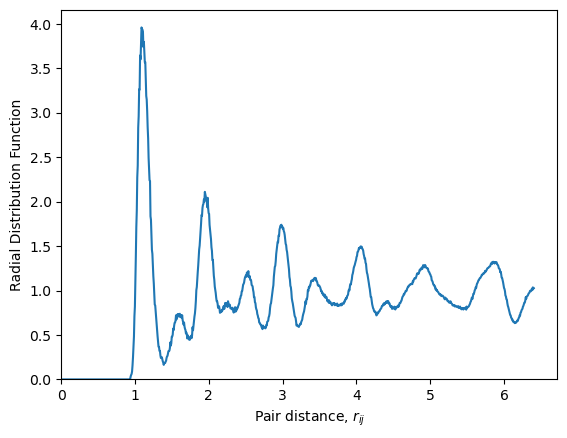

In [6]:
# Create configuration object
configuration = gp.Configuration(D=D, N=N)
configuration.simbox = gp.Orthorhombic(D, output['initial_configuration'].attrs['simbox_data'])
configuration.ptype = output['initial_configuration/ptype']
configuration.copy_to_device()

# Make a radial distribution (RDF) calculator object
calc_rdf = gp.CalculatorRadialDistribution(configuration, bins=1000)

# Loop over the last (-1) configuration in each time block
positions = output['trajectory/positions']  # Shape: nblocks, nconfs, N, D
first_timeblock = 1
for pos in positions[first_timeblock:, -1, :, :]:
    configuration['r'] = pos
    configuration.copy_to_device()
    calc_rdf.update()
rdf_data = calc_rdf.read()

# Plot RDF
plt.figure()
plt.plot(rdf_data['distances'], rdf_data['rdf'][:,0,0])
plt.xlabel(r'Pair distance, $r_{ij}$')
plt.ylabel('Radial Distribution Function')
plt.xlim(0, None)
plt.ylim(0, None)
plt.savefig(filename+'_rdf.pdf')
plt.show()

## Dynamics

There are also built-in tools for analysing the trajectory. For example, the `gamdpy.tools.calc_dynamics` function computes several dynamical measures, including the mean squared displacement and the intermediate scattering function.

In [7]:
qvalues = 7.5
dynamics = gp.tools.calc_dynamics(output, first_block=1, qvalues=qvalues)  # Dictionary with dynamics
dynamics.keys()

dict_keys(['times', 'msd', 'alpha2', 'qvalues', 'Fs', 'count'])

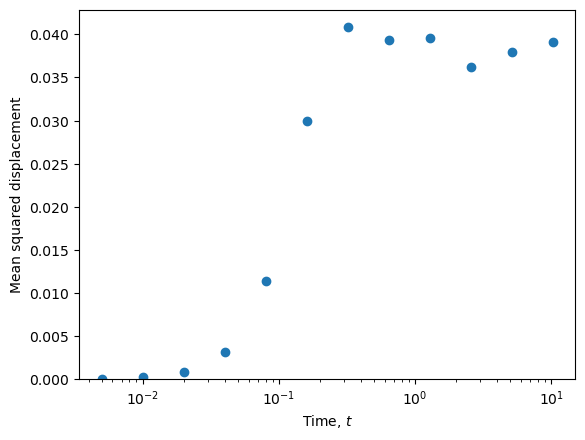

In [8]:
plt.figure()
plt.plot(dynamics['times'], dynamics['msd'], 'o')
plt.xscale('log')
plt.ylim(0, None)
plt.xlabel(r'Time, $t$')
plt.ylabel(r'Mean squared displacement')
plt.show()

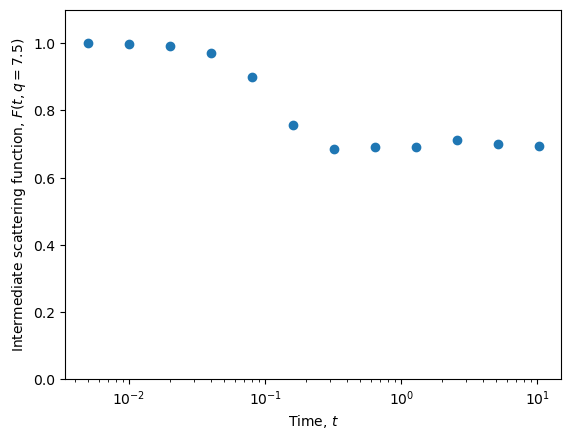

In [9]:
plt.figure()
plt.plot(dynamics['times'], dynamics['Fs'], 'o')
plt.xscale('log')
plt.ylim(0, 1.1)
plt.xlabel(r'Time, $t$')
plt.ylabel(r'Intermediate scattering function, $F(t, q = ' f'{qvalues}' r'$)')
plt.show()

## Details about stored data

### Structure of h5 file
Below is a function to print the structure of a given h5 file.

In [10]:
gp.tools.print_h5_structure(output)

initial_configuration/ (Group)
    ptype  (Dataset, shape=(2048,), dtype=int32)
    r_im  (Dataset, shape=(2048, 3), dtype=int32)
    scalars  (Dataset, shape=(2048, 4), dtype=float32)
    topology/ (Group)
        angles  (Dataset, shape=(0,), dtype=int32)
        bonds  (Dataset, shape=(0,), dtype=int32)
        dihedrals  (Dataset, shape=(0,), dtype=int32)
        molecules/ (Group)
    vectors  (Dataset, shape=(3, 2048, 3), dtype=float32)
restarts/ (Group)
    restart0000/ (Group)
        ptype  (Dataset, shape=(2048,), dtype=int32)
        r_im  (Dataset, shape=(2048, 3), dtype=int32)
        scalars  (Dataset, shape=(2048, 4), dtype=float32)
        topology/ (Group)
            angles  (Dataset, shape=(0,), dtype=int32)
            bonds  (Dataset, shape=(0,), dtype=int32)
            dihedrals  (Dataset, shape=(0,), dtype=int32)
            molecules/ (Group)
        vectors  (Dataset, shape=(3, 2048, 3), dtype=float32)
    restart0001/ (Group)
        ptype  (Dataset, shape=(2

### Attributes inside the H5 file
Below is a function that will print the attributes in a given h5 file.

In [11]:
gp.tools.print_h5_attributes(output)

Attributes at /:
    - dt: 0.005
    - script_content: ...
    - script_name: ...
Attributes at /initial_configuration/:
    - simbox_data: [12.815602 12.815602 12.815602]
    - simbox_name: Orthorhombic
Attributes at /initial_configuration/scalars:
    - scalar_columns: ['U' 'W' 'K' 'm']
Attributes at /initial_configuration/topology/molecules/:
    - names: []
Attributes at /initial_configuration/vectors:
    - vector_columns: ['r' 'v' 'f']
Attributes at /restarts/:
    - timeblocks_between_restarts: 1
Attributes at /restarts/restart0000/:
    - simbox_data: [12.815602 12.815602 12.815602]
    - simbox_name: Orthorhombic
Attributes at /restarts/restart0000/scalars:
    - scalar_columns: ['U' 'W' 'K' 'm']
Attributes at /restarts/restart0000/topology/molecules/:
    - names: []
Attributes at /restarts/restart0000/vectors:
    - vector_columns: ['r' 'v' 'f']
Attributes at /restarts/restart0001/:
    - simbox_data: [12.815602 12.815602 12.815602]
    - simbox_name: Orthorhombic
Attributes

## Concluding remarks

You have now conducted your first simulation and done some post-analysis of the trajectory. You now understand the basics of how gamdpy works, and are ready for more advanced simulations and analysis - see examples.